# Hourly data on the traffic volume for a major interstate highway in the US

Kelompok 9 Kelas B (Smart City)
1. Atalla Fathrelian Banureswara (5027261008)
2. Siti Aisyah (5027261044)
3. Azzam Ahmad Muharrar (5027261135)

# Latar Belakang
Lalu lintas merupakan komponen yang penting dalam infrastruktur tata wilayah atau kota. Selama ini, kemacetan atau fluktuasi volume kendaraan telah menjadi salah satu tantangan utama dalam perencanaan Smart City. Kelompok kami tertarik membahas masalah tersebut untuk project EDA Statistika dan Probabilitas ini. Kami menemukan sebuah dataset yang merekam volume kendaraan per jam di ruas jalan tol lintas negara bagian yang dilengkapi dengan berbagai variabel pendukung. Variabel seperti kondisi cuaca dan temperatur dapat mempengaruhi keputusan dan perilaku masyarakat dalam berkendara. Oleh karena itu, analisis statistik deskriptif ini dilakukan untuk memahami pola pemusatan dan penyebaran data, serta melihat gambaran volume lalu lintas ini dalam bentuk grafik. 

Melalui project ini, kami ingin menjawab beberapa pertanyaan spesifik, yaitu:
1. Berapa nilai rata-rata, median, serta seberapa besar variasi dari volume lalu lintas (`traffic_volume`) per jam pada dataset ini?
 2. Kondisi cuaca utama (`weather_main`) apa yang paling sering muncul (modus), dan berapa persentase kemunculannya?
3. Berapa nilai median volume lalu lintas (`traffic_volume`) pada masing-masing kategori kondisi cuaca utama (`weather_main`)?

In [4]:
import pandas as pd # import library bernama pandas dengan alias pd

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv") # membaca file csv lalu simpan ke variabel bernama df
# df (DataFrame) adalah struktur yang bentuknya tabel 2 dimensi (baris kolom)

print(df.shape)   # menampilkan jumlah baris dan kolom
df.head() # menampilkan 5 baris pertama tabel. [df.head(10) kalo mau nampilin 10 data]

(48204, 9)


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2/10/2012 9:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2/10/2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2/10/2012 13:00


Setiap baris pada dataset mewakili data yang dikumpulkan pada interval waktu 1 jam di waktu yang berbeda.

## Deskripsi data
* **Source**: Kaggle (https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume/data?select=Metro_Interstate_Traffic_Volume.csv)
* **License**: Attribution 4.0 International (CC BY 4.0)
* **Author**: Hogue, John
* The data was collected by the Minnesota Department of Transportation (MnDOT) from 2012 to 2018 at a station roughly midway between the two cities.
* 48204 Rows and 9 Columns
| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
| --- | --- | --- | --- | --- | --- |
| `holiday` | Penanda hari libur nasional atau khusus | Kualitatif | Nominal | - | None, Columbus Day |
| `temp` | Rata-rata suhu udara pada jam tersebut | Kuantitatif kontinu | Interval | Kelvin (K) | 288.28 |
| `rain_1h` | Jumlah curah hujan pada jam tersebut | Kuantitatif kontinu | Rasio | mm | 0.0 |
| `snow_1h` | Jumlah curah salju pada jam tersebut | Kuantitatif kontinu | Rasio | mm | 0.0 |
| `clouds_all` | Persentase tutupan awan di langit | Kuantitatif diskret | Rasio | % | 40 |
| `weather_main` | Kategori tutupan awan di langit | Kualitatif | Nominal | - | Clouds, Clear, Rain |
| `weather_description` | Deskripsi rinci kondisi cuaca saat itu | Kualitatif | Nominal | - | scatter clouds, light rain |
| `date_time` | Tanggal dan jam pencatatan data | Kuantitatif kontinu dan diskret | Interval | YYYY-MM-DD HH:MM:SS | 2012-10-02 09:00:00 |
| `traffic_volume` | Total volume kendaraan yang melintas | Kuantitatif diskret | Rasio | Kendaraan | 5545 |

In [31]:
df.info()                 # tipe data setiap kolom
df.isna().sum()         # jumlah data kosong per kolom
df.duplicated().sum()    # jumlah baris duplikat

<class 'pandas.DataFrame'>
Index: 48177 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48177 non-null  int64         
 1   holiday              48177 non-null  str           
 2   temp                 48177 non-null  float64       
 3   rain_1h              48177 non-null  float64       
 4   snow_1h              48177 non-null  float64       
 5   clouds_all           48177 non-null  int64         
 6   weather_main         48177 non-null  str           
 7   weather_description  48177 non-null  str           
 8   date_time            48177 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 5.0 MB


np.int64(0)

## Temuan Pemeriksaan Kualitas Data
* (`holiday`) hanya ada 61 baris terisi dan sisanya kosong. Ini menunjukkan bahwa sebagian besar hari adalah hari biasa (bukan hari libur). Kami mengisinya dengan "Non-Holiday" sebagai penanda hari biasa agar tidak perlu menghapus semua data yang kosong.
* (`date_time`) kami ubah dari string ke tipe datetime untuk memudahkan ekstraksi variabel seperti jam, hari, atau bulan.
* (`temp`) terdapat 10 baris data yang mencatat suhu sebesar 0.0 Kelvin, secara nyata angka ini setara dengan -273 Celcius dan tidak masuk akal untuk terjadi. Baris ini akan kami hapus karena jumlahnya sangat kecil dan tidak akan merusak distribusi data.
* Terdapat 17 baris duplikat. Baris ini akan kami hapus karena jumlahnya sangat kecil dan tidak akan merusak distribusi data.

In [6]:
# Mengisi nilai kosong pada kolom holiday agar tidak perlu dihapus
df['holiday'] = df['holiday'].fillna('Non-Holiday')
# memilih kolom holiday dari df dan cari nilai kosong ganti dengan 'Non-Holiday' lalu simpan kembali perubahan ke kolom holiday

# Menghapus baris duplikat (17 baris)
#df = df.drop_duplicates().reset_index(drop=True)
df = df.drop_duplicates()
# mencari dan menghapus baris duplikat, kemudian rapikan indeks dan buang indeks lama yang berantakan

# Mengubah tipe data date_time dari string menjadi format datetime
df['date_time'] = pd.to_datetime(df['date_time'], format = 'mixed')

# Menghapus baris temp yang bernilai 0
df = df[df['temp'] > 0]

# Cek kembali kualitas data setelah dibersihkan
print("Jumlah baris & kolom setelah pembersihan:", df.shape)

Jumlah baris & kolom setelah pembersihan: (48177, 9)


In [7]:
#3 kolom yang akan dianalisis
kolom_list = ['traffic_volume', 'temp', 'snow_1h', 'rain_1h', 'clouds_all']
s = df[kolom_list] #membuat fungsi atau ringkasan perhitungan untuk setiap data

tabel_ringkasan = pd.DataFrame({
    'Mean': s.mean(),
    'Median': s.median(),
    'Mode': s.mode().iloc[0],
    'Min': s.min(),
    'Max': s.max(),
    'Jangkauan': s.max() - s.min(),
    'Varians': s.var(),
    'Simpangan Baku': s.std(),
    'Q1': s.quantile(0.25),
    'Q3': s.quantile(0.75),
    'IQR': s.quantile(0.75) - s.quantile(0.25)
})

display(tabel_ringkasan)

,Mean,Median,Mode,Min,Max,Jangkauan,Varians,Simpangan Baku,Q1,Q3,IQR
traffic_volume,3260.021110,3380.00,353.00,0.00,7280.00,7280.00,3.947590e+06,1986.854244,1194.00,4933.00,3739.00
temp,281.263364,282.46,274.15,243.39,310.07,66.68,1.615414e+02,12.709895,272.18,291.81,19.63
snow_1h,0.000223,0.00,0.00,0.00,0.51,0.51,6.674723e-05,0.008170,0.00,0.00,0.00
rain_1h,0.334451,0.00,0.00,0.00,9831.30,9831.30,2.007191e+03,44.801682,0.00,0.00,0.00
clouds_all,49.375698,64.00,90.00,0.00,100.00,100.00,1.521997e+03,39.012778,1.00,90.00,89.00


## Analisis Statistik Deskriptif Variabel Numerik

1. **Volume Lalu Lintas (`traffic_volume`):**
   * Memiliki mean sekitar 3.260 kendaraan/jam, sedangkan mediannya sekitar 3.380 kendaraan/jam. Karena nilai mean dan median relatif mirip, distribusi volume kendaraan cenderung menyebar secara seimbang. Ada jam-jam ramai dan sepi dalam porsi yang pas.
   * Memiliki nilai standar deviasi sekitar 1.986 dan rentang antarkuartil (IQR) yang besar, artinya ada perbedaan volume lalu lintas yang sangat tinggi antara siang/malam maupun hari kerja/libur.
2. **Kondisi Cuaca (`temp`, `snow_1h`, `rain_1h`, `clouds_all`):**
   * (`temp`) memiliki meean dan median yang mirip, artinya distribusi datanya menyebar cukup merata.
   * (`snow`) memiliki median 0 yang menandakan salju sangat jarang turun. Sedangkan nilai mean mengindikasikan beberapa kejadian salju dengan volume tertentu.
   * (`rain_1h`) memiliki median 0 yang menandakan hujan sangat jarang turun. Sedangkan nilai mean mengindikasikan beberapa kejadian hujan dengan volume tertentu.
   * (`clouds_all`) memiliki nilai mean < median yang berarti sebagian besar waktu pengamatan kondisi langit tertutup awan.

In [8]:
# Tabel Frekuensi & Persentase Cuaca Utama (weather_main)
freq_weather = df['weather_main'].value_counts()
pct_weather = df['weather_main'].value_counts(normalize=True) * 100
tabel_weather = pd.DataFrame({'Jumlah': freq_weather, 'Persentase (%)': pct_weather.round(2)})
print(tabel_weather)

print("\n" + "="*70 + "\n")

# Tabel Frekuensi Hari Libur (hanya yang bukan 'Non-Holiday')
freq_libur = df['holiday'].value_counts()
pct_libur = df['holiday'].value_counts(normalize=True) * 100
tabel_libur = pd.DataFrame({'Jumlah': freq_libur, 'Persentase (%)': pct_libur.round(2)})
print(tabel_libur)

print("\n" + "="*70 + "\n")

# Tabel Frekuensi Hari Libur (hanya yang bukan 'Non-Holiday')
freq_condition = df['weather_description'].value_counts()
pct_condition = df['weather_description'].value_counts(normalize=True) * 100
tabel_condition = pd.DataFrame({'Jumlah': freq_condition, 'Persentase (%)': pct_condition.round(2)})
print(tabel_condition)

              Jumlah  Persentase (%)
weather_main                        
Clouds         15158           31.46
Clear          13374           27.76
Mist            5949           12.35
Rain            5672           11.77
Snow            2875            5.97
Drizzle         1820            3.78
Haze            1360            2.82
Thunderstorm    1033            2.14
Fog              912            1.89
Smoke             20            0.04
Squall             4            0.01


                           Jumlah  Persentase (%)
holiday                                          
Non-Holiday                 48116           99.87
Labor Day                       7            0.01
Thanksgiving Day                6            0.01
Christmas Day                   6            0.01
New Years Day                   6            0.01
Martin Luther King Jr Day       6            0.01
Columbus Day                    5            0.01
Veterans Day                    5            0.01
Washingtons Birth

## Analisis Statistik Deskriptif Variabel Kategorik

1. **Kondisi Cuaca (`weather_main`):** Kategori cuaca yang paling sering muncul adalah "Clouds (berawan)".
2. **Status Hari Libur (`holiday`):** Dapat diketahui bahwa proporsi hari biasa atau hari kerja "Non-Holiday" sangat mendominasi dataset.
3. **Deskripsi Cuaca (`weather_description`):** Kondisi cuaca yang paling sering muncul adalah "sky is clear"

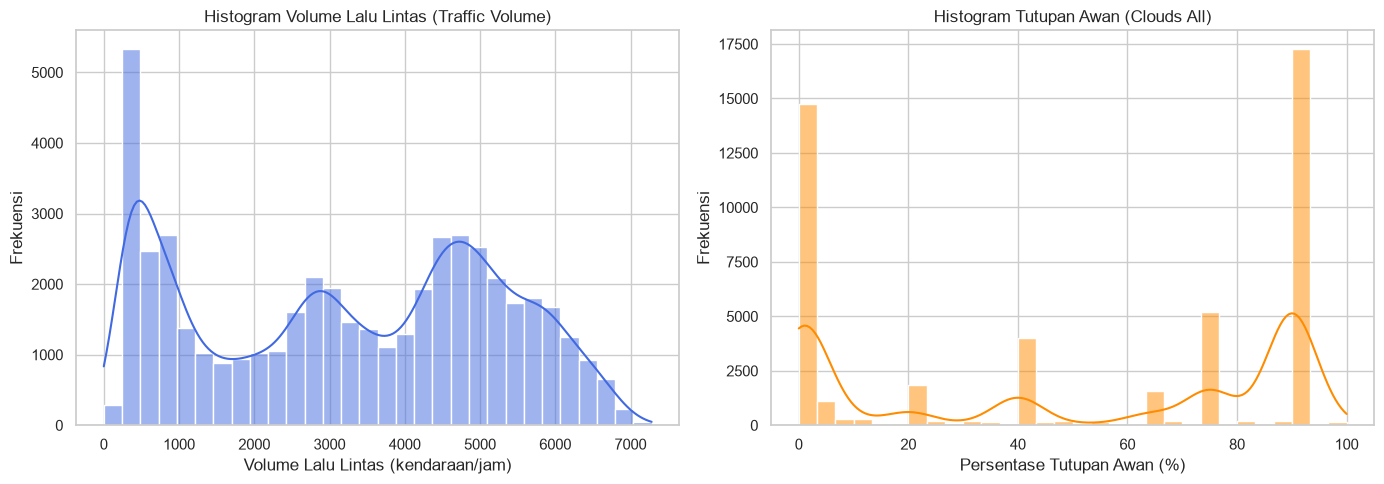

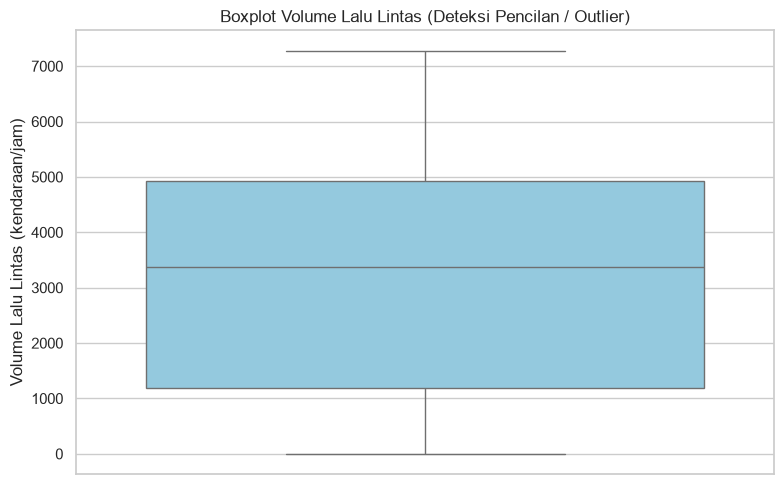

   PENGECEKAN OUTLIER - TRAFFIC VOLUME
Q1 (Kuartil 1)          : 1194.00
Q3 (Kuartil 3)          : 4933.00
IQR (Q3 - Q1)           : 3739.00
Batas Bawah (Q1-1.5IQR) : -4414.50
Batas Atas  (Q3+1.5IQR) : 10541.50
---------------------------------------------
Jumlah Outlier          : 0 baris
Persentase Outlier      : 0.00% dari total data

Tidak ada outlier yang terdeteksi.


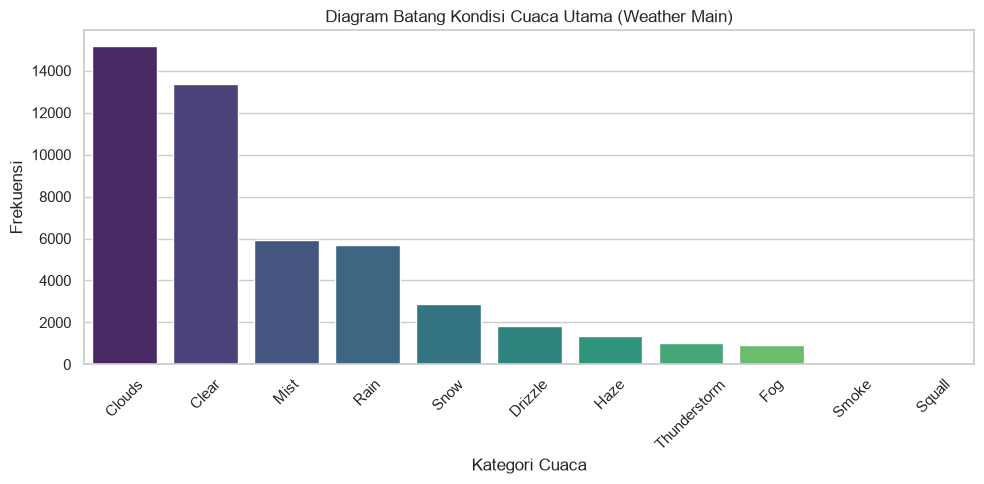

In [21]:
import pandas as pd #Mengimpor pustaka pandas untuk manipulasi dan analisis data
import numpy as np #Mengimpor pustaka numpy untuk komputasi numerik
import matplotlib.pyplot as plt #Mengimpor pustaka matplotlib untuk membuat visualisasi grafik 
import seaborn as sns #Mengimpor pustaka seaborn untuk visualisasi data statistik yang lebih menarik

# Atur tema visualisasi
sns.set_theme(style="whitegrid") #Mengatur tema tampilan seaborn dengan latar belakang garis kisi putih

# --- A. Histogram untuk 2 Kolom Numerik ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) #Membuat kanvas figur dengan 1 baris dan 2 kolom subplot berukuran 14x5

# Histogram 1: Volume Lalu Lintas
sns.histplot(df['traffic_volume'], bins=30, kde=True, ax=axes[0], color='royalblue') #Membuat histogram distribusi volume lalu lintas dengan kurva KDE di subplot pertama
axes[0].set_title('Histogram Volume Lalu Lintas (Traffic Volume)') #Memberikan judul pada subplot pertama
axes[0].set_xlabel('Volume Lalu Lintas (kendaraan/jam)') #Memberikan label pada sumbu X subplot pertama
axes[0].set_ylabel('Frekuensi') #Memberikan label pada sumbu Y subplot pertama

# Histogram 2: Tutupan Awan (Clouds All)
sns.histplot(df['clouds_all'], bins=30, kde=True, ax=axes[1], color='darkorange') #Membuat histogram distribusi tutupan awan dengan kurva KDE di subplot kedua
axes[1].set_title('Histogram Tutupan Awan (Clouds All)') #Memberikan judul pada subplot kedua
axes[1].set_xlabel('Persentase Tutupan Awan (%)') #Memberikan label pada sumbu X subplot kedua
axes[1].set_ylabel('Frekuensi') #Memberikan label pada sumbu Y subplot kedua

plt.tight_layout() #Mengatur tata letak subplot agar tidak saling tumpang tindih secara otomatis
plt.show() #Menampilkan plot gabungan histogram ke layar

# --- B. Boxplot untuk Deteksi Pencilan (Traffic Volume) ---
plt.figure(figsize=(8, 5))  # Membuat figur baru berukuran 8 inci x 5 inci untuk menampung grafik boxplot
sns.boxplot(y=df['traffic_volume'], color='skyblue')  # Membuat boxplot vertikal dari kolom 'traffic_volume' dengan warna skyblue
plt.title('Boxplot Volume Lalu Lintas (Deteksi Pencilan / Outlier)')  # Menambahkan judul pada grafik boxplot
plt.ylabel('Volume Lalu Lintas (kendaraan/jam)')  # Memberi label pada sumbu Y sebagai keterangan satuan volume lalu lintas
plt.tight_layout()  # Mengatur tata letak agar semua elemen grafik tidak terpotong dan pas di dalam jendela
plt.show()  # Menampilkan grafik boxplot ke layar


# --- C. Pengecekan Outlier dengan Rumus 1.5 x IQR ---
Q1 = df['traffic_volume'].quantile(0.25)  # Menghitung Kuartil 1 (nilai pada persentil ke-25) dari kolom traffic_volume
Q3 = df['traffic_volume'].quantile(0.75)  # Menghitung Kuartil 3 (nilai pada persentil ke-75) dari kolom traffic_volume
IQR = Q3 - Q1  # Menghitung IQR (Interquartile Range) = selisih antara Q3 dan Q1

# Batas bawah & batas atas
lower_bound = Q1 - 1.5 * IQR  # Menghitung batas bawah wajar = Q1 dikurangi 1.5 kali IQR
upper_bound = Q3 + 1.5 * IQR  # Menghitung batas atas wajar = Q3 ditambah 1.5 kali IQR

print("=" * 45)  # Mencetak garis pemisah "=" sebanyak 45 karakter sebagai pembuka output
print("   PENGECEKAN OUTLIER - TRAFFIC VOLUME")  # Mencetak judul bagian pengecekan outlier
print("=" * 45)  # Mencetak garis pemisah "=" sebanyak 45 karakter setelah judul
print(f"Q1 (Kuartil 1)          : {Q1:.2f}")  # Menampilkan nilai Q1 dengan 2 angka di belakang koma
print(f"Q3 (Kuartil 3)          : {Q3:.2f}")  # Menampilkan nilai Q3 dengan 2 angka di belakang koma
print(f"IQR (Q3 - Q1)           : {IQR:.2f}")  # Menampilkan nilai IQR dengan 2 angka di belakang koma
print(f"Batas Bawah (Q1-1.5IQR) : {lower_bound:.2f}")  # Menampilkan batas bawah wajar dengan 2 angka di belakang koma
print(f"Batas Atas  (Q3+1.5IQR) : {upper_bound:.2f}")  # Menampilkan batas atas wajar dengan 2 angka di belakang koma
print("-" * 45)  # Mencetak garis pemisah "-" sebanyak 45 karakter

# Identifikasi outlier
outliers = df[(df['traffic_volume'] < lower_bound) | 
              (df['traffic_volume'] > upper_bound)]  # Memfilter baris yang nilai traffic_volume-nya di bawah batas bawah ATAU di atas batas atas (disebut outlier)

print(f"Jumlah Outlier          : {len(outliers)} baris")  # Menampilkan jumlah baris yang terdeteksi sebagai outlier
print(f"Persentase Outlier      : {len(outliers)/len(df)*100:.2f}% dari total data")  # Menghitung & menampilkan persentase outlier terhadap total data
print("=" * 45)  # Mencetak garis pemisah "=" sebanyak 45 karakter sebagai penutup

# Tampilkan beberapa contoh outlier
if len(outliers) > 0:  # Mengecek apakah ada outlier (jika jumlahnya lebih dari 0)
    print("\nContoh data outlier:")  # Mencetak judul untuk daftar contoh outlier
    print(outliers[['date_time', 'traffic_volume']].head(10))  # Menampilkan 10 baris pertama outlier, hanya kolom date_time dan traffic_volume
else:  # Jika tidak ada outlier (jumlahnya 0)
    print("\nTidak ada outlier yang terdeteksi.")  # Mencetak pesan bahwa tidak ada outlier
    
# --- C. Diagram Batang untuk Kolom Kategorik (Weather Main) ---
plt.figure(figsize=(10, 5)) # Membuat figur baru untuk diagram batang dengan ukuran 10x5
weather_counts = df['weather_main'].value_counts()# Menghitung jumlah kemunculan dari setiap kategori cuaca utama

# Memperbaiki parameter palette dengan menambahkan hue dan legend=False
sns.barplot(
    x=weather_counts.index,# Menentukan kategori cuaca pada sumbu X 
    y=weather_counts.values, # Menentukan frekuensi jumlah data pada sumbu Y
    hue=weather_counts.index, # Menetapkan warna berdasarkan kategori agar sesuai standar seaborn terbaru
    palette='viridis', # Menggunakan skema warna 'viridis'
    legend=False # Menyembunyikan legenda karena warna sudah merepresentasikan kategori sumbu X
)

plt.title('Diagram Batang Kondisi Cuaca Utama (Weather Main)') # Memberikan judul pada diagram batang
plt.xlabel('Kategori Cuaca')# Memberikan label pada sumbu X diagram batang
plt.ylabel('Frekuensi')# Memberikan label pada sumbu Y diagram batang
plt.xticks(rotation=45)# Memutar label teks pada sumbu X sebesar 45 derajat agar mudah dibaca
plt.tight_layout()# Mengatur tata letak agar pas dan rapi
plt.show()# Menampilkan diagram batang ke layar

**Histogram Volume Lalu Lintas (Traffic Volume)**

Bentuk sebaran miring ke kanan (Right-skewed). Grafik ini menggambarkan seberapa sering (frekuensi) tingkat kepadatan volume kendaraan (dalam satuan kendaraan/jam) terjadi. 

**Histogram Tutupan Awan (Clouds All)**

 Bentuk sebaran tidak simetris, memiliki dua puncak ekstrem di kedua ujung. 

**Boxplot Volume Lalu Lintas (Deteksi Pencilan / Outlier)**

Pencilan ditandai dengan titik yang berada di luar garis batas (whiskers), pada grafik ini semua titik berada di dalam rentang garis whisker.

**Diagram Batang Kondisi Cuaca Utama (Weather Main)**

Paling Dominan : Kategori Clouds (>15.000 data) dan clear(sekitar 13.300 data) mendominasi secara signifikan.
Tingkat Menengah: Kategori cuaca basah/lembap seperti Mist (sekitar 5.900) dan Rain (sekitar 5.600) berada di posisi sedang
Sangat Langka: Cuaca ekstrem seperti Squall dan Smoke memiliki frekuensi paling rendah (hampir 0)

In [10]:
# Mengelompokkan berdasarkan 'weather_main' lalu menghitung median 'traffic_volume'
median_cuaca = df.groupby('weather_main')['traffic_volume'].median().reset_index()

# Mengurutkan hasil dari median tertinggi ke terkecil
median_cuaca = median_cuaca.sort_values(by='traffic_volume', ascending=False)

# Menampilkan hasil tabelnya
display(median_cuaca)

,weather_main,traffic_volume
1,Clouds,4071.0
4,Haze,3987.0
7,Smoke,3612.0
6,Rain,3497.5
2,Drizzle,3475.0
8,Snow,3080.0
0,Clear,3045.5
10,Thunderstorm,2969.0
5,Mist,2800.0
3,Fog,2339.0


## Kesimpulan
1. **Berapa nilai rata-rata, median, serta seberapa besar variasi dari volume lalu lintas (`traffic_volume`) per jam pada dataset ini?**


   Nilai mean sekitar 3.260 dan median sekitar 3.380. Besarnya variasi volume lalu lintas (ditunjukkan oleh simpangan baku dan rentang) mengindikasikan bahwa pola lalu lintas di ruas jalan ini sangat dinamis dan bergantung pada waktu. Angka mean saja tidak cukup menggambarkan kondisi jalan karena fluktuasi antara jam sepi dan padat sangat kontras.
   
 2. **Kondisi cuaca utama (`weather_main`) apa yang paling sering muncul (modus), dan berapa persentase kemunculannya?**

    Kondisi cuaca utama yang paling sering muncul adalah Clouds (berawan) dengan persentase 31,46%.

    
 3. **Berapa nilai median volume lalu lintas (`traffic_volume`) pada masing-masing kategori kondisi cuaca utama (`weather_main`)?**

    | Index | weather_main | traffic_volume |
    | :---: | :--- | :---: |
    | **1** | Clouds | 4071.0 |
    | **4** | Haze | 3987.0 |
    | **7** | Smoke | 3612.0 |
    | **6** | Rain | 3497.5 |
    | **2** | Drizzle | 3475.0 |
    | **8** | Snow | 3080.0 |
    | **0** | Clear | 3045.5 |
    | **10** | Thunderstorm | 2969.0 |
    | **5** | Mist | 2800.0 |
    | **3** | Fog | 2339.0 |
    | **9** | Squall | 1818.0 |



**Temuan menarik yang didapat:**
1. (`weather_description`) shower snow hanya terjadi sekali
2. Ketika cuaca berawan, volume kendaraan paling banyak dibanding cuaca cerah
3. Dataset didominasi oleh (`holiday`) Non-Holiday atau hari biasa dengan persentasi 99.87%
  
**Keterbatasan data:**
  1. Tidak tahu bagaimana data diambil
  2. (`holiday`) punya banyak data kosong
  3. (`temp`) terdapat data aneh yaitu 0.0 Kelvin

**Ide pertanyaan lanjutan:**
  1. Bagaimana pola perbedaan volume lalu lintas (traffic_volume) berdasarkan jam dalam sehari (jam sibuk vs jam sepi) dan hari dalam seminggu (hari kerja vs akhir pekan)?

## Referensi dan Catatan Penggunaan AI
* Sumber dataset: Kaggle (https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume/data?select=Metro_Interstate_Traffic_Volume.csv)

**Referensi belajar:**
* Buat tabel: https://youtu.be/kfjlDN19_BA?si=X_p2ohpdh5HC1smF
* Menentukan kamus data: Materi kelas 

**Catatan AI Gemini**
| Nomor | Dipakai untuk |
| :--- | :--- |
| 1 | Membantu kami memahami maksud dan tujuan penugasan serta apa saja yang harus kami lakukan |
| 2 | Membantu kami untuk mengimport data dari kaggle |
| 3 | Memberitahu cara membuat tabel karena kami gatau caranya |
| 4 | Mencari tahu suatu jenis data cocoknya ditampilin dengan grafik apa |
| 5 | Mencari tahu cara kerja suatu code |
| 6 | Membantu memperbagus grafik |
| 7 | Cara membuka jupyter notebook |
| 8 | Membantu menyusun pertanyaan yang ingin dijawab |
| 9 | Memberitahu cara mengatasi suatu eror |
| 10 | Membantu memahami analisis data |